# Introducción a OpenCV y espacios de color

**Duración estimada:** 75 minutos

## Objetivo

En este cuaderno vas a empezar a moverte por una imagen con OpenCV. La meta no es solo abrir una foto, sino entender cómo leer coordenadas, cómo se representan los colores y por qué a veces conviene trabajar en `HSV` en lugar de hacerlo directamente en `RGB`.

## Resultados de aprendizaje

Al final vas a poder:

- ubicar un punto dentro de una imagen usando coordenadas `x` e `y`;
- explicar la diferencia entre `BGR`, `RGB` y `HSV`;
- separar canales y mirar qué información aporta cada uno;
- construir una máscara simple por color sobre una imagen real.

## Idea central del cuaderno

Vamos a trabajar con una imagen de globos porque tiene una ventaja didáctica fuerte: la escena es visualmente rica, los colores están bastante separados y eso nos permite discutir umbrales sin que el ejemplo sea artificial.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()


Forma de la imagen: (1024, 1024, 3)
Tipo de dato: uint8
Recordá: OpenCV lee en BGR. Para mostrar con Matplotlib conviene convertir a RGB.


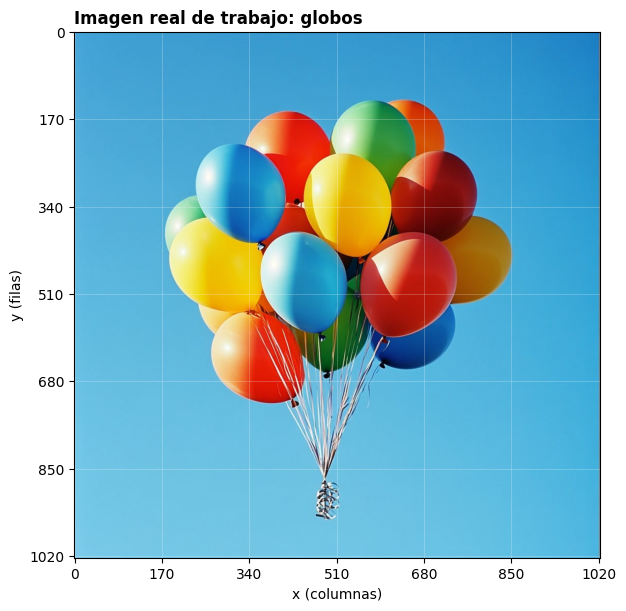

In [2]:
imagen_bgr = abrir_imagen_bgr("globos.jpg")
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

print("Forma de la imagen:", imagen_bgr.shape)
print("Tipo de dato:", imagen_bgr.dtype)
print("Recordá: OpenCV lee en BGR. Para mostrar con Matplotlib conviene convertir a RGB.")

mostrar_una_imagen(imagen_rgb, "Imagen real de trabajo: globos")

## 1. Cómo orientarse dentro de una imagen

Antes de segmentar, detectar o medir, hace falta saber cómo moverse dentro de la imagen.

- El origen está en la esquina superior izquierda.
- `x` indica la columna: cuando te movés hacia la derecha, `x` crece.
- `y` indica la fila: cuando te movés hacia abajo, `y` crece.

Esta convención aparece una y otra vez en OpenCV. Si no te resulta clara, después se vuelve difícil entender recortes, máscaras, cajas o contornos.


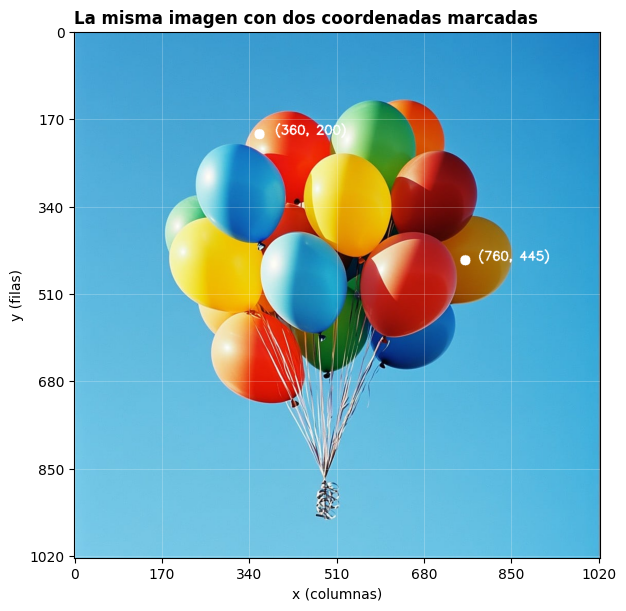

In [3]:
imagen_coordenadas = imagen_rgb.copy()

# Marcamos dos puntos para leer coordenadas concretas sobre la imagen.
coordenada_1 = (760, 445)
coordenada_2 = (360, 200)

cv2.circle(imagen_coordenadas, coordenada_1, 10, (255, 255, 255), -1)
cv2.circle(imagen_coordenadas, coordenada_2, 10, (255, 255, 255), -1)

cv2.putText(imagen_coordenadas, "(760, 445)", (785, 445), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
cv2.putText(imagen_coordenadas, "(360, 200)", (390, 200), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

mostrar_una_imagen(imagen_coordenadas, "La misma imagen con dos coordenadas marcadas")


**Qué mirar en la salida**

- Las marcas blancas se ubican usando pares `(x, y)`.
- Si quisieras recortar una región, dibujar una caja o medir un contorno, esas coordenadas serían tu punto de partida.

En las visualizaciones de este bloque vamos a dejar visibles los ejes justamente para reforzar esa lectura espacial.


## 2. Una imagen puede representarse de distintas maneras

La escena es la misma, pero la forma de organizar los datos cambia según la tarea.

- En **RGB** leemos rojo, verde y azul.
- En **escala de grises** nos quedamos solo con intensidad luminosa.
- En **HSV** separamos matiz, saturación y valor; eso suele ser muy útil cuando queremos segmentar por color.


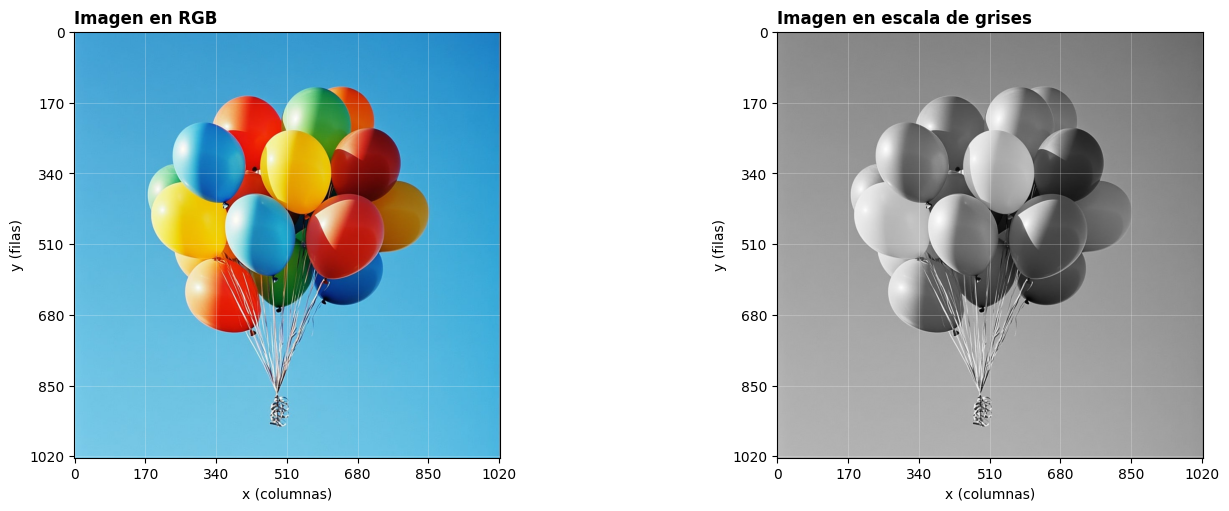

In [4]:
imagen_grises = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

mostrar_varias_imagenes(
    [imagen_rgb, imagen_grises],
    ["Imagen en RGB", "Imagen en escala de grises"],
    [None, "gray"],
    tamano=(14, 5),
)


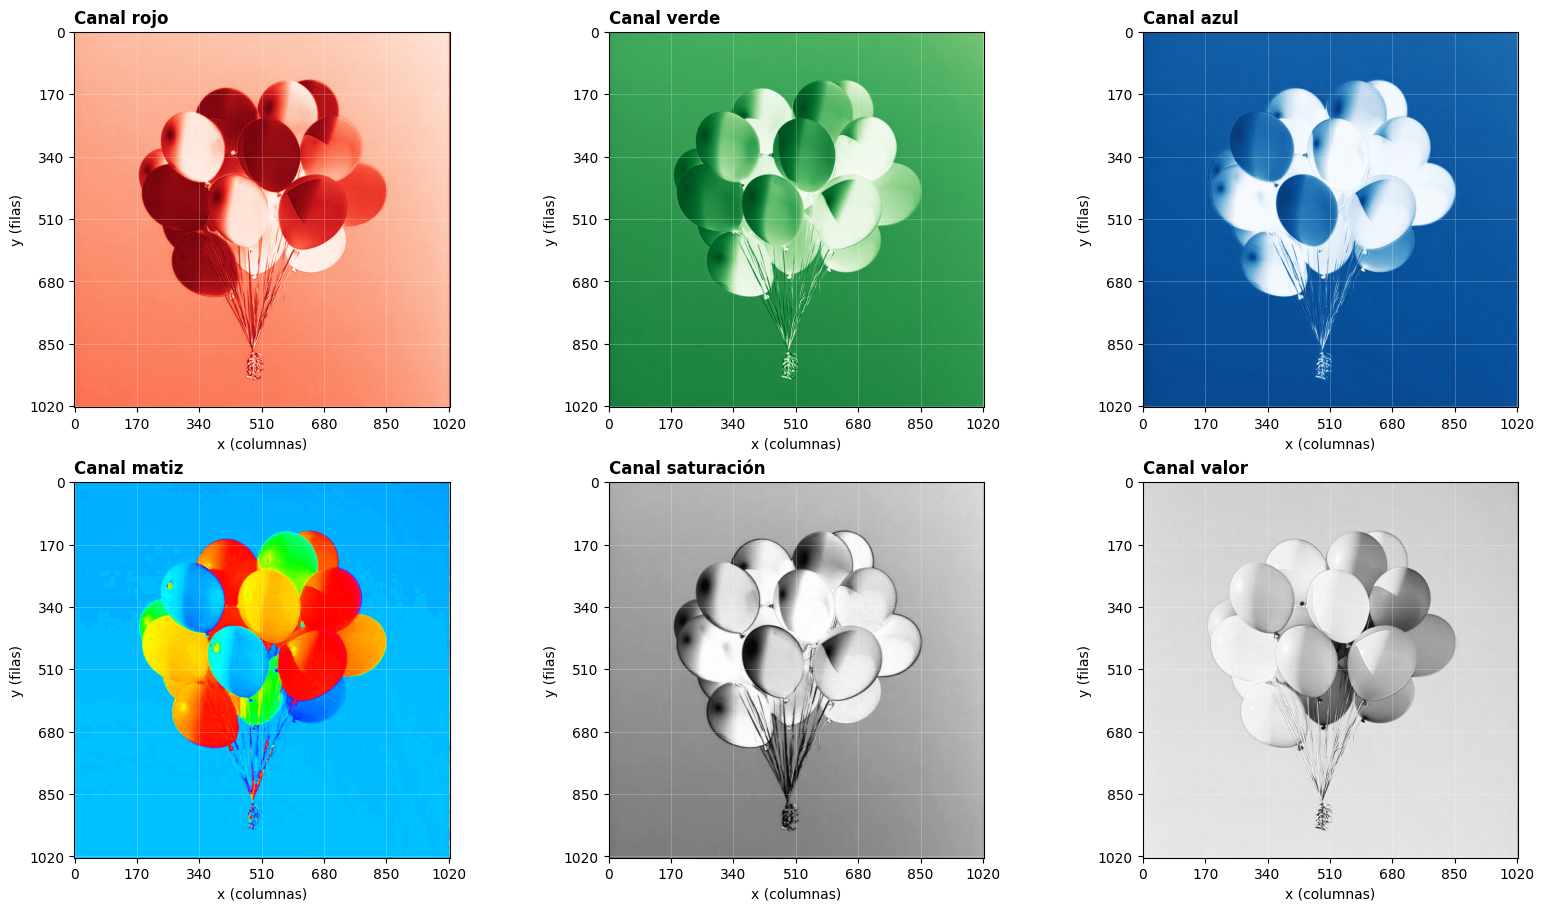

In [5]:
canal_rojo = imagen_rgb[:, :, 0]
canal_verde = imagen_rgb[:, :, 1]
canal_azul = imagen_rgb[:, :, 2]

canal_matiz = imagen_hsv[:, :, 0]
canal_saturacion = imagen_hsv[:, :, 1]
canal_valor = imagen_hsv[:, :, 2]

fig, ejes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

preparar_eje_imagen(ejes[0, 0], canal_rojo, "Canal rojo", "Reds")
preparar_eje_imagen(ejes[0, 1], canal_verde, "Canal verde", "Greens")
preparar_eje_imagen(ejes[0, 2], canal_azul, "Canal azul", "Blues")
preparar_eje_imagen(ejes[1, 0], canal_matiz, "Canal matiz", "hsv")
preparar_eje_imagen(ejes[1, 1], canal_saturacion, "Canal saturación", "gray")
preparar_eje_imagen(ejes[1, 2], canal_valor, "Canal valor", "gray")

plt.show()


## 3. Segmentación por color en una imagen real

Una escena compleja permite ver que segmentar no es “apretar un botón”, sino elegir rangos y luego evaluar si lo que quedó seleccionado coincide o no con la intención inicial.

Vamos a buscar **globos naranjas**. No hace falta que el resultado sea perfecto. Lo importante es aprender a leer qué quedó adentro y qué quedó afuera.


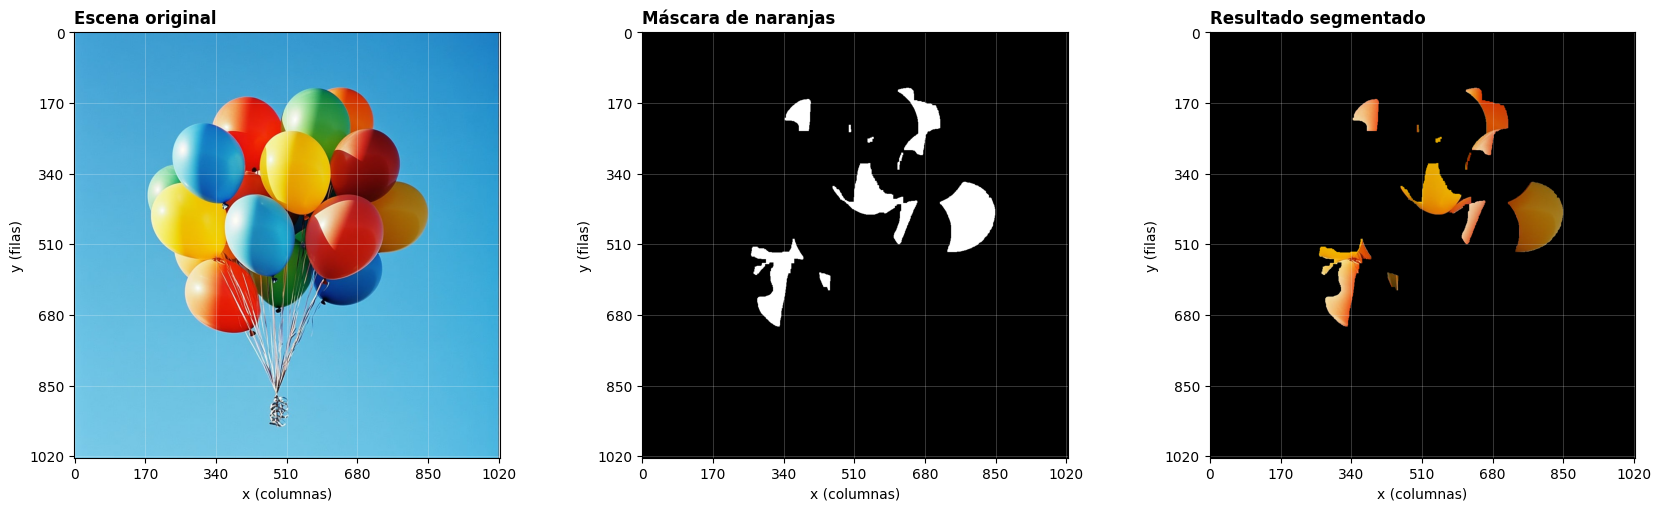

Porcentaje de píxeles seleccionados: 4.50%


In [6]:
# Definimos un rango de naranjas en HSV.
rango_naranja_bajo = np.array([8, 80, 80])
rango_naranja_alto = np.array([22, 255, 255])

# Creamos una máscara binaria: blanco para lo seleccionado, negro para el resto.
mascara_naranja = cv2.inRange(imagen_hsv, rango_naranja_bajo, rango_naranja_alto)

# Limpiamos ruido pequeño con operaciones morfológicas simples.
kernel = np.ones((5, 5), np.uint8)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, kernel, iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, kernel, iterations=2)

# Aplicamos la máscara sobre la imagen RGB.
resultado_naranja = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara_naranja)

mostrar_varias_imagenes(
    [imagen_rgb, mascara_naranja, resultado_naranja],
    ["Escena original", "Máscara de naranjas", "Resultado segmentado"],
    [None, "gray", None],
    tamano=(17, 5),
)

porcentaje = 100 * np.count_nonzero(mascara_naranja) / mascara_naranja.size
print(f"Porcentaje de píxeles seleccionados: {porcentaje:.2f}%")


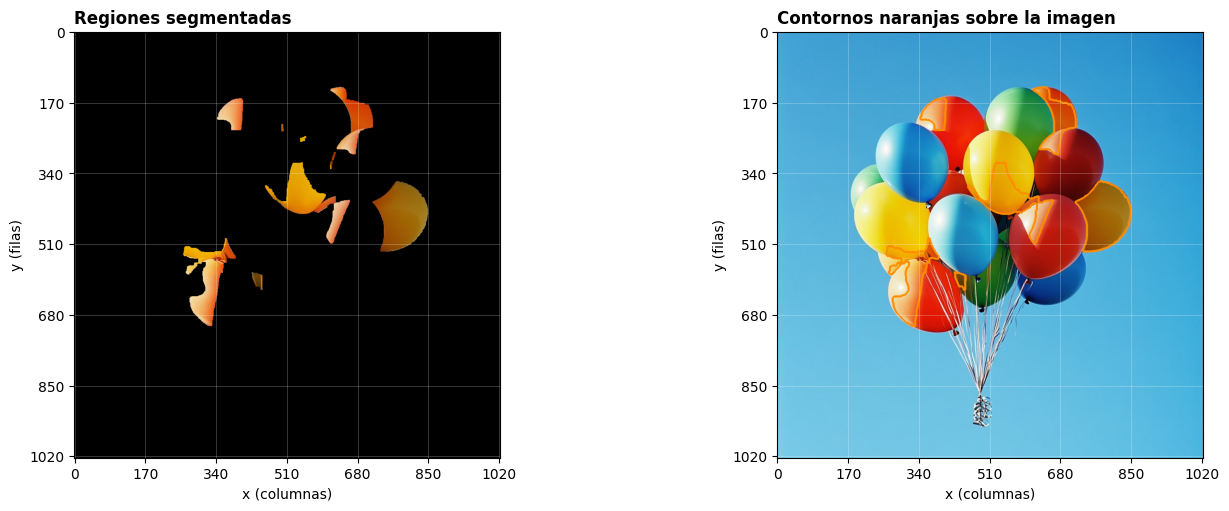

In [7]:
contornos_en_mascara, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

imagen_con_contornos = imagen_rgb.copy()
for contorno in contornos_en_mascara:
    area = cv2.contourArea(contorno)
    if area > 500:
        cv2.drawContours(imagen_con_contornos, [contorno], -1, (255, 140, 0), 3)

mostrar_varias_imagenes(
    [resultado_naranja, imagen_con_contornos],
    ["Regiones segmentadas", "Contornos naranjas sobre la imagen"],
    [None, None],
    tamano=(14, 5),
)


## Cierre

En este primer cuaderno aparecen tres ideas que van a volver en todo el bloque:

- leer coordenadas con seguridad;
- elegir una representación útil para el problema;
- mirar críticamente la salida en lugar de aceptar cualquier resultado visual.

**Actividad breve**

Cambiá el rango `HSV` para intentar seleccionar otro grupo de globos. Después anotá qué cambió en la máscara y por qué.
